# TDGSA Deep Scope Notebook
## A 1000+ line exploratory Jupyter notebook for dispersion-assisted optical phase recovery

This notebook is intentionally broad and technical. It is designed to scope the project from:
- **left to right**: source to measurement to recovery
- **right to left**: reconstruction back to source constraints
- **up and down**: abstraction level vs implementation detail
- **into and out of**: individual operators, units, and system boundaries

It focuses on:
- classical Gerchberg–Saxton
- time-domain GS analogs
- dispersive propagation
- carrier-less optical communication framing
- unit and dimensional analysis
- communication metrics
- simple machine-learning baselines
- engineering economics and workflow control

This notebook is based on the project brief and supporting papers, but it is still a reconstruction and exploration notebook rather than a final validated lab notebook.

## 0. Why this notebook exists

The project brief asks for:
1. familiarity with Gerchberg–Saxton
2. investigation of the time-domain equivalent and time-stretch phase retrieval
3. Python code for Gaussian pulses with engineered phase profiles
4. a Colab/Jupyter simulator for the system in the 2009 TDGSA paper
5. simulation of phase recovery on optical communication data to be provided later

This notebook is the large-scoped exploratory backbone for all of those tasks.

## 1. Imports and environment

In [1]:
import re
import glob
from pathlib import Path
from math import pi

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

try:   
    import torch
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 8
plt.rcParams["lines.linewidth"] = 1.2

print("Torch available:", TORCH_AVAILABLE)

Torch available: True


## 2. Project scope and source alignment

### Project brief interpretation

The project is explicitly about an **advanced receiver technique** in optical communication.
The intended application is a **carrier-less coherent receiver**, meaning the receiver tries to recover phase from intensity-only measurements rather than from explicit mixing with a local oscillator.

### Important consequences

That means the notebook cannot stop at:
- pretty plots
- pulse cartoons
- a single FFT/IFFT demonstration

It must move toward:
- two-measurement reconstruction
- parameter and unit tracking
- communication-style signals
- performance metrics that matter for a receiver

### Minimum scientific stack

The brief and the papers naturally suggest these layers:
- field model
- measurement model
- propagation model
- algorithm model
- evaluation model
- deployment/economic model

## 3. Symbol glossary

We will use the following symbols throughout the notebook.

- `t`: time, seconds
- `f`: ordinary frequency, Hz
- `ω`: angular frequency, rad/s
- `λ`: wavelength, meters
- `E(t)`: complex field envelope in time
- `E(ω)`: complex field in frequency
- `|E|^2`: intensity
- `D`: dispersion parameter, often quoted in ps/nm
- `β2`: group velocity dispersion coefficient
- `L`: propagation length
- `β2L`: lumped second-order phase coefficient
- `D1`, `D2`: two distinct dispersive measurements
- `φ(t)`, `ψ(ω)`: time- and frequency-domain phases

## 4. Left/right and up/down mental map

### Left to right
Source field → channel/spectral shaping → dispersive measurement 1 and 2 → recorded intensities → iterative reconstruction → recovered field → communication decisions

### Right to left
Recovered field → consistency with measurement 2 → inverse propagation → consistency with measurement 1 → back to improved source estimate

### Up/down
At the top level, this is a receiver-architecture question.
At the lower level, it is a sequence of FFT-based operators and amplitude-replacement rules.

### Into/out of
Every operator should be understood locally:
- what goes in
- what comes out
- what the units are
- what assumptions are hidden

## 5. Core numerical helpers

In [2]:
def normalize(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    return (x - x.min()) / (x.max() - x.min() + eps)

def power(x):
    return np.abs(x) ** 2

def complex_field(amplitude, phase):
    return amplitude * np.exp(1j * phase)

def fftc(x):
    return np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x)))

def ifftc(X):
    return np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(X)))

def fft2c(x):
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(x)))

def ifft2c(X):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(X)))

def make_grid(N, dt):
    t = (np.arange(N) - N // 2) * dt
    f = np.fft.fftshift(np.fft.fftfreq(N, d=dt))
    w = 2 * np.pi * f
    return t, f, w

def signed_display(a, lo=1.0, hi=99.0):
    a = np.asarray(a, dtype=np.float64)
    vmin, vmax = np.percentile(a, [lo, hi])
    return normalize(np.clip(a, vmin, vmax))

## 6. Global parameter block

In [3]:
PARAMS = {
    "N1D": 4096,
    "dt": 5e-12,  # 200 Gsps
    "T0_ns": 2.0,
    "tau_ns": 20.0,
    "C_gas": 1.0,
    "D1_gas_ps_nm": -353.0,
    "D2_gas_ps_nm": -872.0,
    "D1_cubic_ps_nm": -600.0,
    "D2_cubic_ps_nm": -900.0,
    "n_iter": 100,
    "dataset_examples": 32,
    "dataset_symbols": 64,
    "dataset_sps": 16,
    "dataset_noise_std": 0.01,
}
PARAMS

{'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'C_gas': 1.0,
 'D1_gas_ps_nm': -353.0,
 'D2_gas_ps_nm': -872.0,
 'D1_cubic_ps_nm': -600.0,
 'D2_cubic_ps_nm': -900.0,
 'n_iter': 100,
 'dataset_examples': 32,
 'dataset_symbols': 64,
 'dataset_sps': 16,
 'dataset_noise_std': 0.01}

## 7. Unit and dimensional analysis, part I: the basic grids

The most frequent source of failure in these projects is not the FFT itself.
It is usually a quiet inconsistency in:
- time step
- frequency step
- angular frequency scaling
- dispersion units
- normalization conventions

So we start with the discrete grid relations.

In [4]:
N_sym, dt_sym = sp.symbols("N dt", positive=True, real=True)
df_sym = 1 / (N_sym * dt_sym)
df_sym

1/(N*dt)

For a discrete signal sampled with:
- `N` points
- sample spacing `dt`

the ordinary frequency spacing is:

$
df = \frac{1}{N\,dt}
$

and the angular frequency spacing is:

$
d\omega = 2\pi df = \frac{2\pi}{N\,dt}
$

In [ ]:
dw_sym = 2 * sp.pi / (N_sym * dt_sym)
dw_sym

## 8. Unit and dimensional analysis, part II: dispersive propagation

A second-order dispersive operator is often written as:

$
H(\omega) = \exp\left(-j \frac{1}{2} \beta_2 L \omega^2\right)
$

The exponential argument must be dimensionless.

In [5]:
beta2L_sym, omega_sym = sp.symbols("beta2L omega", real=True)
phase_arg = sp.Rational(1, 2) * beta2L_sym * omega_sym**2
phase_arg

beta2L*omega**2/2

Dimension check:

- `ω` has units of `1/s`
- `ω²` has units of `1/s²`
- therefore `β2L` must have units of `s²`

This is why the product `β2L` is often the cleanest object numerically.

## 9. Unit and dimensional analysis, part III: relation between D and β2

In [6]:
c_sym, lam_sym, D_sym = sp.symbols("c lambda D", positive=True, real=True)
beta2_sym = -(lam_sym**2 / (2 * sp.pi * c_sym)) * D_sym
beta2_sym

-D*lambda**2/(2*pi*c)

A commonly used continuous relation is:

$
\beta_2 = -\frac{\lambda^2}{2\pi c} D
$
provided the units are handled consistently.

In [7]:
def beta2L_from_ps_per_nm(d_ps_nm, scale=1e-26):
    # Exploratory placeholder.
    # Replace with a physically validated conversion when the exact lab convention is known.
    return d_ps_nm * scale

## 10. Why the placeholder conversion still helps

Even though the conversion above is not yet a final physical model, it still supports useful exploratory work:
- algorithm wiring
- convergence behavior
- sweep scripts
- plotting
- dataset generation
- interface design between blocks

## 11. Pulse models

In [8]:
def gaussian_envelope(t, T0):
    return np.exp(-0.5 * (t / T0) ** 2)

def chirped_gaussian(t, T0, tau, C=1.0):
    amp = gaussian_envelope(t, T0)
    phase = C * (t / tau) ** 2
    return amp * np.exp(1j * phase)

def cubic_phase_pulse(t, T0, alpha=3.0):
    amp = gaussian_envelope(t, T0)
    phase = alpha * (t / T0) ** 3
    return amp * np.exp(1j * phase)

def quadratic_phase_pulse(t, T0, alpha=1.0):
    amp = gaussian_envelope(t, T0)
    phase = alpha * (t / T0) ** 2
    return amp * np.exp(1j * phase)

## 12. Visualizing pulse families

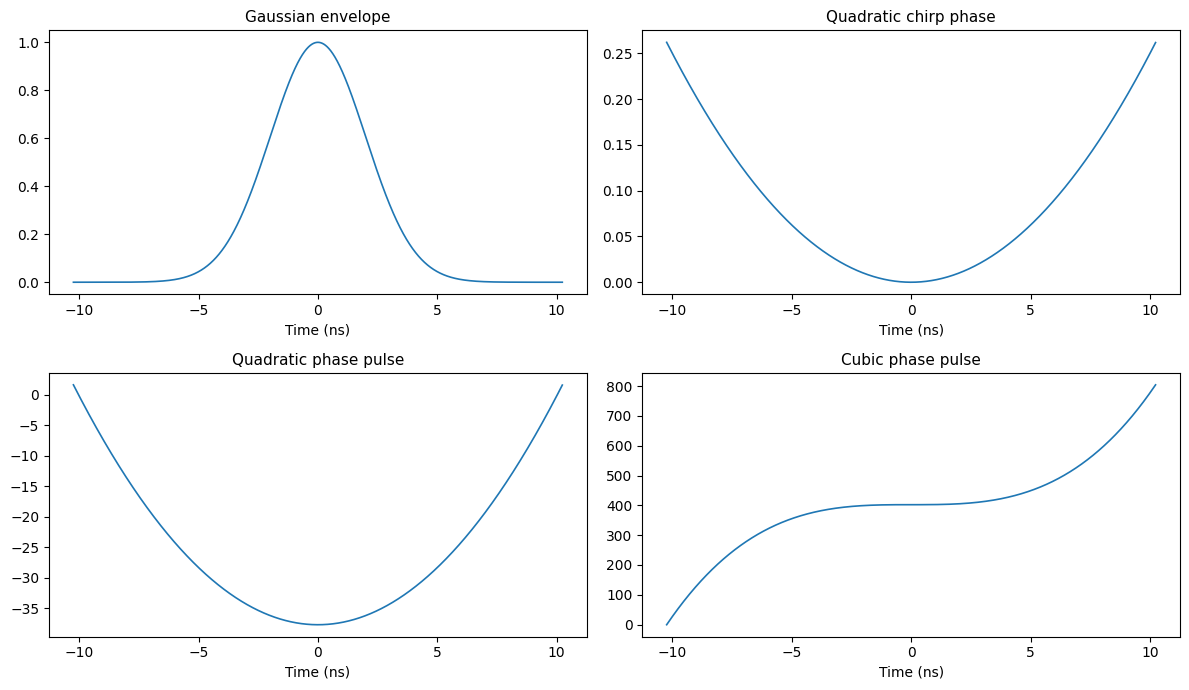

In [9]:
t, f, w = make_grid(PARAMS["N1D"], PARAMS["dt"])
T0 = PARAMS["T0_ns"] * 1e-9
tau = PARAMS["tau_ns"] * 1e-9

Eg = gaussian_envelope(t, T0)
Ec = chirped_gaussian(t, T0, tau, C=PARAMS["C_gas"])
Eq = quadratic_phase_pulse(t, T0, alpha=1.5)
E3 = cubic_phase_pulse(t, T0, alpha=3.0)

fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax[0, 0].plot(t * 1e9, normalize(np.abs(Eg)))
ax[0, 0].set_title("Gaussian envelope")
ax[0, 1].plot(t * 1e9, np.unwrap(np.angle(Ec)))
ax[0, 1].set_title("Quadratic chirp phase")
ax[1, 0].plot(t * 1e9, np.unwrap(np.angle(Eq)))
ax[1, 0].set_title("Quadratic phase pulse")
ax[1, 1].plot(t * 1e9, np.unwrap(np.angle(E3)))
ax[1, 1].set_title("Cubic phase pulse")
for a in ax.ravel():
    a.set_xlabel("Time (ns)")
plt.tight_layout()
plt.show()

## 13. Spectral absorption placeholder and KK-like phase

In [10]:
def notch_spectrum(f, centers_hz, widths_hz, depths):
    A = np.ones_like(f, dtype=np.float64)
    for fc, bw, d in zip(centers_hz, widths_hz, depths):
        A *= (1.0 - d * np.exp(-0.5 * ((f - fc) / bw) ** 2))
    return np.clip(A, 1e-6, None)

def kk_like_phase(amplitude_spectrum):
    logA = np.log(np.clip(amplitude_spectrum, 1e-9, None))
    freq = np.fft.fftfreq(logA.size)
    H = -1j * np.sign(freq)
    return np.imag(np.fft.ifft(np.fft.fft(logA) * H))

def apply_spectral_absorption(E_t, f, centers_hz, widths_hz, depths, causal_phase=True):
    E_w = fftc(E_t)
    A = notch_spectrum(f, centers_hz, widths_hz, depths)
    phi = kk_like_phase(A) if causal_phase else np.zeros_like(A)
    return ifftc(E_w * A * np.exp(1j * phi)), A, phi

## 14. Compare causal and noncausal notch behavior

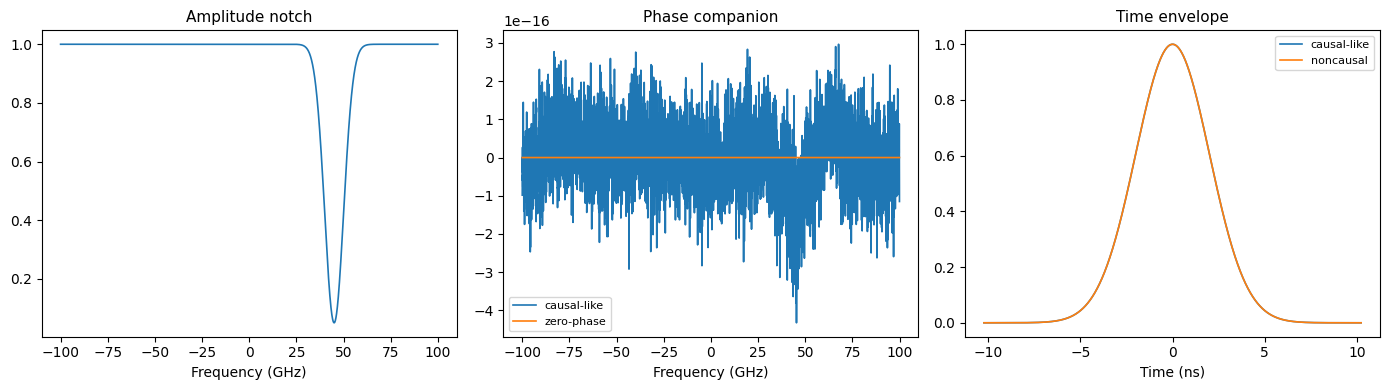

In [11]:
E0 = chirped_gaussian(t, T0, tau, C=1.0)
E_causal, A_causal, phi_causal = apply_spectral_absorption(
    E0, f, [45e9], [5e9], [0.95], causal_phase=True
)
E_noncausal, A_noncausal, phi_noncausal = apply_spectral_absorption(
    E0, f, [45e9], [5e9], [0.95], causal_phase=False
)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(f / 1e9, A_causal)
ax[0].set_title("Amplitude notch")
ax[0].set_xlabel("Frequency (GHz)")
ax[1].plot(f / 1e9, phi_causal, label="causal-like")
ax[1].plot(f / 1e9, phi_noncausal, label="zero-phase")
ax[1].set_title("Phase companion")
ax[1].set_xlabel("Frequency (GHz)")
ax[1].legend()
ax[2].plot(t * 1e9, normalize(np.abs(E_causal)), label="causal-like")
ax[2].plot(t * 1e9, normalize(np.abs(E_noncausal)), label="noncausal")
ax[2].set_title("Time envelope")
ax[2].set_xlabel("Time (ns)")
ax[2].legend()
plt.tight_layout()
plt.show()

## 15. Interpretation of the causal/noncausal test

This comparison explains one of the slide-deck failure modes.
If the magnitude shaping is imposed without a consistent causal phase:
- the near-field waveform can carry the wrong side-ringing structure
- the TDGSA target becomes inconsistent
- the algorithm may fail for reasons that look like bad convergence but are actually a bad forward model

## 16. Dispersive propagation operator

In [12]:
def apply_dispersion(E_t, w, beta2L):
    E_w = fftc(E_t)
    H = np.exp(-1j * 0.5 * beta2L * w**2)
    return ifftc(E_w * H)

## 17. Visualize one pulse under multiple dispersions

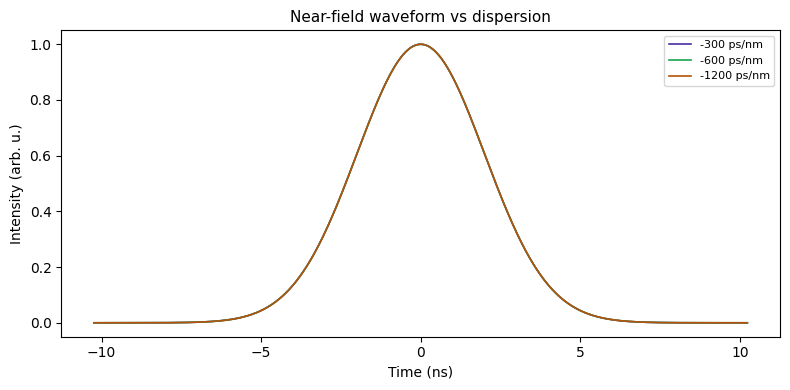

In [13]:
D_values = [-300.0, -600.0, -1200.0]
beta_values = [beta2L_from_ps_per_nm(d) for d in D_values]
single_line, _, _ = apply_spectral_absorption(E0, f, [45e9], [5e9], [0.95], causal_phase=True)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
colors = ["#4b2ca3", "#16a34a", "#b45309"]
for d, b, c in zip(D_values, beta_values, colors):
    E_d = apply_dispersion(single_line, w, b)
    ax.plot(t * 1e9, normalize(np.abs(E_d)), color=c, label=f"{d:.0f} ps/nm")
ax.set_title("Near-field waveform vs dispersion")
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Intensity (arb. u.)")
ax.legend()
plt.tight_layout()
plt.show()

## 18. Right/left view of the algorithm

### Forward direction
Source estimate in plane 1 → propagate to plane 2 → enforce plane 2 amplitude

### Reverse direction
Updated estimate in plane 2 → propagate back to plane 1 → enforce plane 1 amplitude

This left/right alternation is the essence of GS and TDGSA.

## 19. TDGSA core loop

In [14]:
def tdgsa(meas1_amp, meas2_amp, w, beta2L_1, beta2L_2, n_iter=100, init_phase=None):
    if init_phase is None:
        init_phase = np.random.uniform(-np.pi, np.pi, size=meas1_amp.shape)

    E1 = complex_field(meas1_amp, init_phase)
    H12 = np.exp(-1j * 0.5 * (beta2L_2 - beta2L_1) * w**2)
    H21 = np.exp(-1j * 0.5 * (beta2L_1 - beta2L_2) * w**2)

    mag_err = []
    phase_err = []
    history = []
    prev_phase = np.unwrap(np.angle(E1))

    for k in range(n_iter):
        E1 = complex_field(meas1_amp, np.angle(E1))
        E2 = ifftc(fftc(E1) * H12)
        E2 = complex_field(meas2_amp, np.angle(E2))
        E1_new = ifftc(fftc(E2) * H21)

        phase_now = np.unwrap(np.angle(E1_new))
        mag_err.append(np.sqrt(np.mean((np.abs(E1_new)**2 - meas1_amp**2)**2)))
        phase_err.append(np.sqrt(np.mean((phase_now - prev_phase)**2)))

        history.append({
            "iter": k + 1,
            "E1": E1_new.copy(),
            "E2": E2.copy(),
            "mag_err": mag_err[-1],
            "phase_err": phase_err[-1],
        })

        prev_phase = phase_now.copy()
        E1 = E1_new

    return E1, np.array(mag_err), np.array(phase_err), history

## 20. Gas-cell style slide-aligned experiment

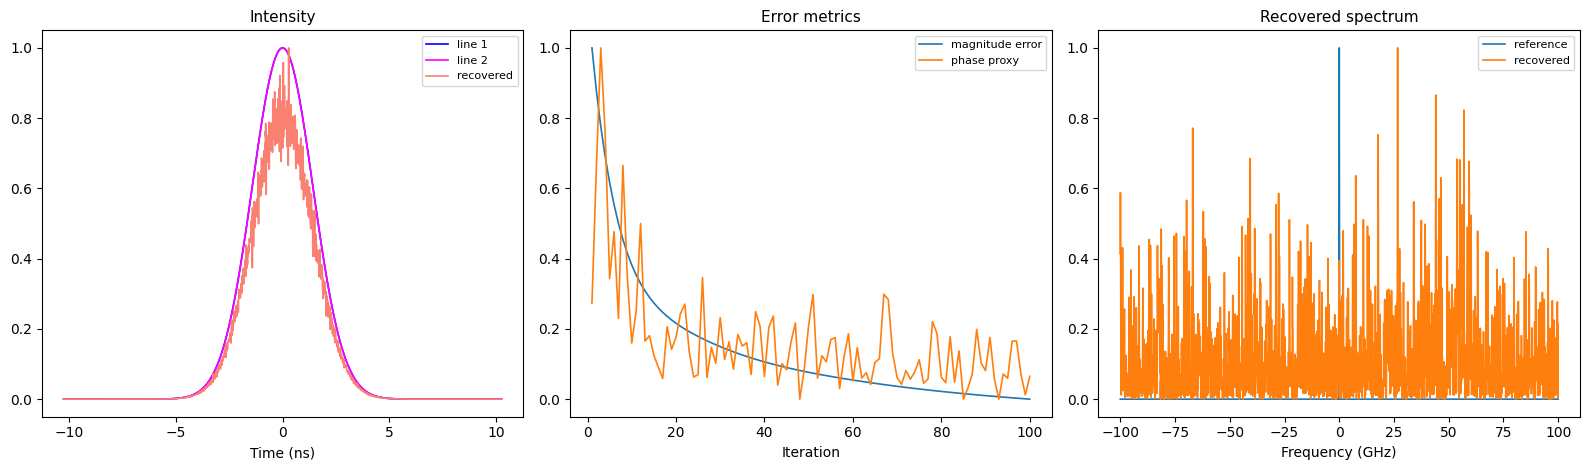

In [15]:
Egas, A_gas, phi_gas = apply_spectral_absorption(
    E0, f,
    centers_hz=[25e9, 60e9, 115e9, 160e9],
    widths_hz=[3e9, 4e9, 3e9, 3e9],
    depths=[0.85, 0.80, 0.86, 0.84],
    causal_phase=True
)

D1g = beta2L_from_ps_per_nm(PARAMS["D1_gas_ps_nm"])
D2g = beta2L_from_ps_per_nm(PARAMS["D2_gas_ps_nm"])

E1g = apply_dispersion(Egas, w, D1g)
E2g = apply_dispersion(Egas, w, D2g)

Erecg, mag_err_g, phase_err_g, hist_g = tdgsa(
    np.abs(E1g), np.abs(E2g), w, D1g, D2g, n_iter=PARAMS["n_iter"]
)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
ax[0].plot(t * 1e9, normalize(power(E1g)), color="blue", label="line 1")
ax[0].plot(t * 1e9, normalize(power(E2g)), color="magenta", label="line 2")
ax[0].plot(t * 1e9, normalize(power(Erecg)), color="salmon", label="recovered")
ax[0].set_title("Intensity")
ax[0].set_xlabel("Time (ns)")
ax[0].legend()
ax[1].plot(np.arange(1, len(mag_err_g)+1), normalize(mag_err_g), label="magnitude error")
ax[1].plot(np.arange(1, len(phase_err_g)+1), normalize(phase_err_g), label="phase proxy")
ax[1].set_title("Error metrics")
ax[1].set_xlabel("Iteration")
ax[1].legend()
ax[2].plot(f / 1e9, normalize(power(fftc(Egas))), label="reference")
ax[2].plot(f / 1e9, normalize(power(fftc(Erecg))), label="recovered")
ax[2].set_title("Recovered spectrum")
ax[2].set_xlabel("Frequency (GHz)")
ax[2].legend()
plt.tight_layout()
plt.show()

## 21. What the gas-cell experiment really tells us

This experiment tells us:
- whether the algorithm wiring is internally consistent
- whether the chosen diversity between `D1` and `D2` is enough to drive iteration
- whether the reconstruction roughly tracks the forward model

It does not yet tell us whether the receiver is communication-feasible.

## 22. Informed initialization vs random initialization

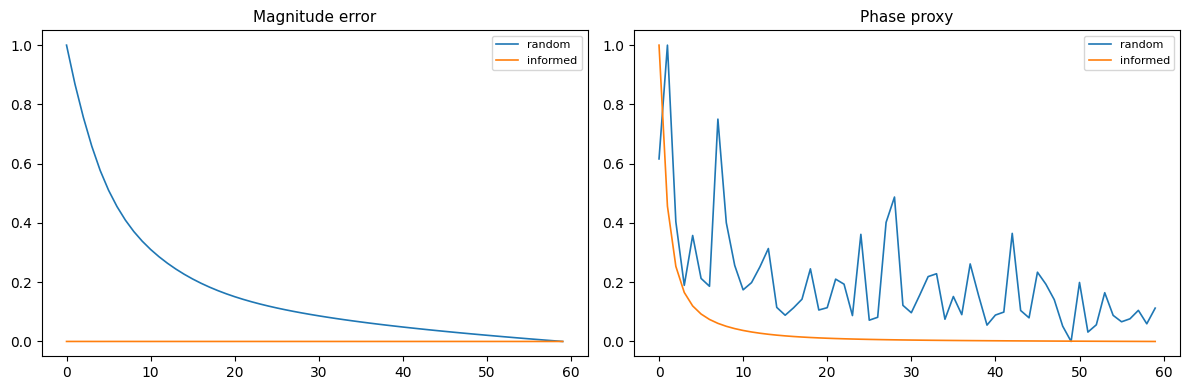

In [16]:
random_init = np.random.uniform(-np.pi, np.pi, size=t.shape)
informed_init = np.angle(chirped_gaussian(t, T0, tau, C=1.0))

_, mag_err_rand, phase_err_rand, _ = tdgsa(
    np.abs(E1g), np.abs(E2g), w, D1g, D2g, n_iter=60, init_phase=random_init
)
_, mag_err_info, phase_err_info, _ = tdgsa(
    np.abs(E1g), np.abs(E2g), w, D1g, D2g, n_iter=60, init_phase=informed_init
)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(normalize(mag_err_rand), label="random")
ax[0].plot(normalize(mag_err_info), label="informed")
ax[0].set_title("Magnitude error")
ax[0].legend()
ax[1].plot(normalize(phase_err_rand), label="random")
ax[1].plot(normalize(phase_err_info), label="informed")
ax[1].set_title("Phase proxy")
ax[1].legend()
plt.tight_layout()
plt.show()

## 23. Even-degree vs odd-degree phase profiles

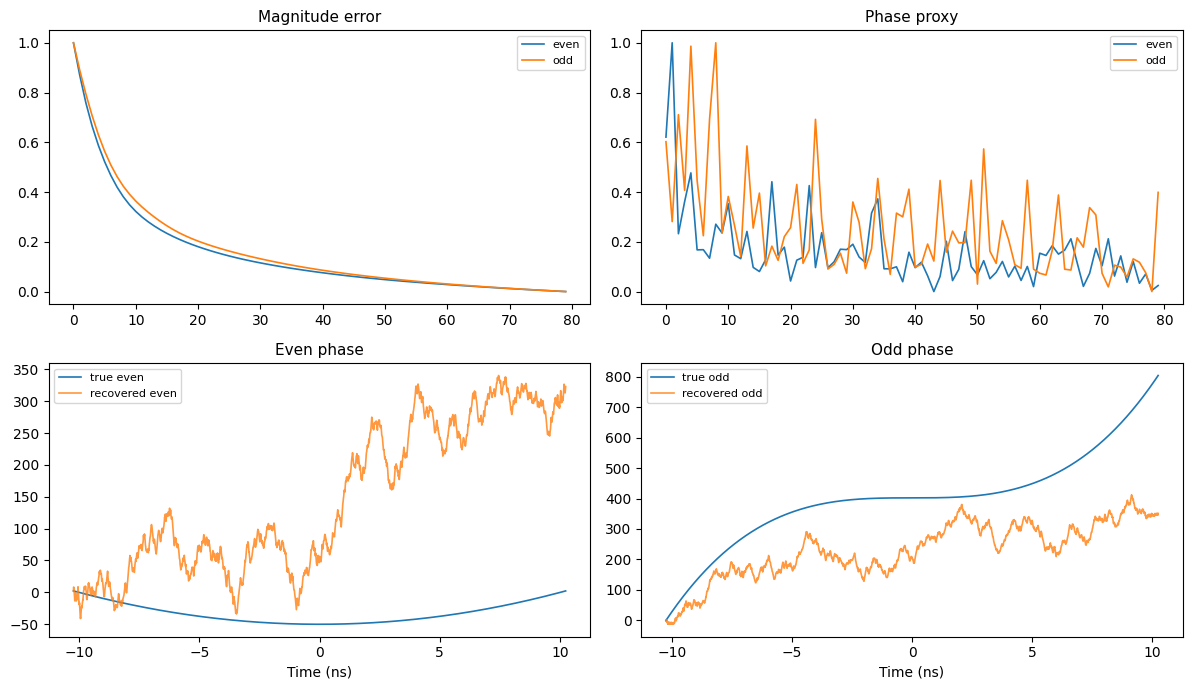

In [17]:
Eq_even = quadratic_phase_pulse(t, T0, alpha=2.0)
Eo_odd = cubic_phase_pulse(t, T0, alpha=3.0)

E1_even = apply_dispersion(Eq_even, w, D1g)
E2_even = apply_dispersion(Eq_even, w, D2g)
E1_odd = apply_dispersion(Eo_odd, w, D1g)
E2_odd = apply_dispersion(Eo_odd, w, D2g)

Erec_even, mag_even, ph_even, _ = tdgsa(np.abs(E1_even), np.abs(E2_even), w, D1g, D2g, n_iter=80)
Erec_odd, mag_odd, ph_odd, _ = tdgsa(np.abs(E1_odd), np.abs(E2_odd), w, D1g, D2g, n_iter=80)

fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax[0, 0].plot(normalize(mag_even), label="even")
ax[0, 0].plot(normalize(mag_odd), label="odd")
ax[0, 0].set_title("Magnitude error")
ax[0, 0].legend()
ax[0, 1].plot(normalize(ph_even), label="even")
ax[0, 1].plot(normalize(ph_odd), label="odd")
ax[0, 1].set_title("Phase proxy")
ax[0, 1].legend()
ax[1, 0].plot(t * 1e9, np.unwrap(np.angle(Eq_even)), label="true even")
ax[1, 0].plot(t * 1e9, np.unwrap(np.angle(Erec_even)), label="recovered even", alpha=0.8)
ax[1, 0].set_title("Even phase")
ax[1, 1].plot(t * 1e9, np.unwrap(np.angle(Eo_odd)), label="true odd")
ax[1, 1].plot(t * 1e9, np.unwrap(np.angle(Erec_odd)), label="recovered odd", alpha=0.8)
ax[1, 1].set_title("Odd phase")
for a in ax[1, :]:
    a.set_xlabel("Time (ns)")
    a.legend()
plt.tight_layout()
plt.show()

## 24. Up/down exploration: from abstract loop to communication objective

At a high level, the reconstruction loop is only useful if it supports a final task.
For the communication case, the task is not merely waveform recovery.
It is closer to:
- symbol recovery
- phase tracking
- error-vector minimization
- decision reliability

## 25. Simple communication signal generation

In [18]:
def qpsk_symbols(n):
    constellation = np.array([1+1j, 1-1j, -1+1j, -1-1j]) / np.sqrt(2)
    idx = np.random.randint(0, 4, size=n)
    return constellation[idx], idx

def shaped_symbol_train(num_symbols=64, sps=16):
    syms, idx = qpsk_symbols(num_symbols)
    up = np.zeros(num_symbols * sps, dtype=np.complex128)
    up[::sps] = syms

    n = np.arange(-4 * sps, 4 * sps + 1)
    pulse = np.exp(-0.5 * (n / (0.6 * sps)) ** 2)
    pulse = pulse / np.sqrt(np.sum(np.abs(pulse) ** 2))

    shaped = np.convolve(up, pulse, mode="same")
    return shaped, idx, pulse

## 26. Generate and inspect one shaped QPSK waveform

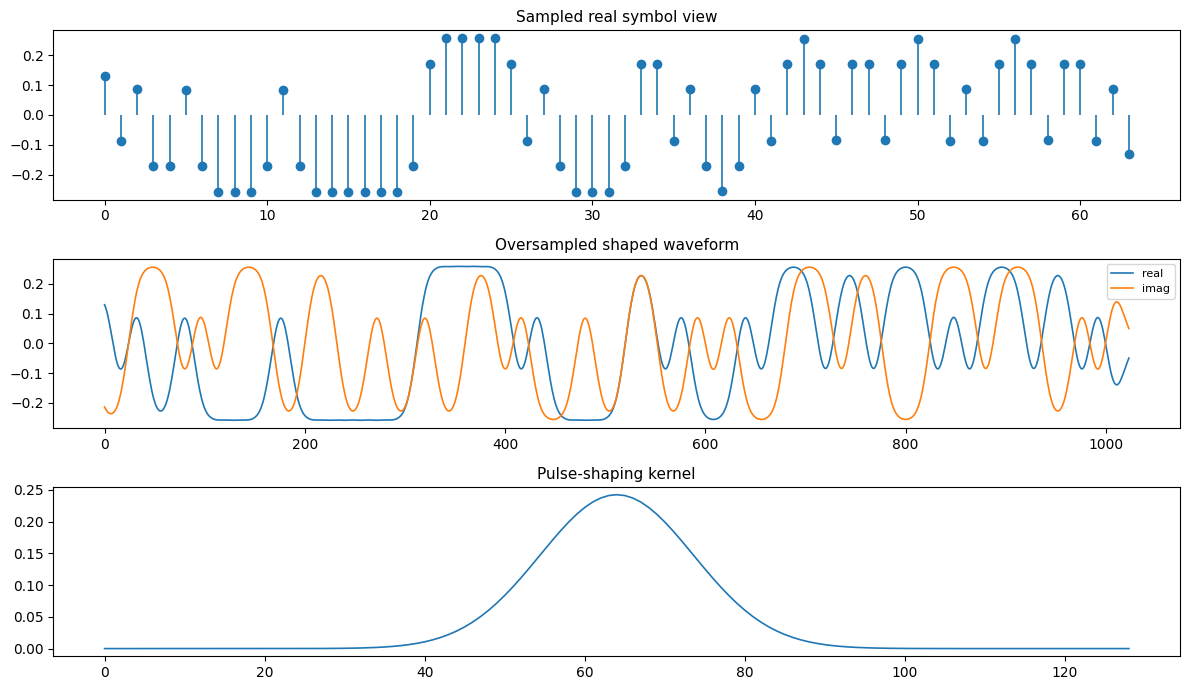

In [19]:
signal_comm, labels_comm, pulse_comm = shaped_symbol_train(num_symbols=64, sps=16)

fig, ax = plt.subplots(3, 1, figsize=(12, 7))
ax[0].stem(np.real(signal_comm[::16]), linefmt="C0-", markerfmt="C0o", basefmt=" ")
ax[0].set_title("Sampled real symbol view")
ax[1].plot(np.real(signal_comm), label="real")
ax[1].plot(np.imag(signal_comm), label="imag")
ax[1].set_title("Oversampled shaped waveform")
ax[1].legend()
ax[2].plot(np.real(pulse_comm))
ax[2].set_title("Pulse-shaping kernel")
plt.tight_layout()
plt.show()

## 27. Communication dataset generator

In [20]:
def make_comm_dataset(num_examples=32, num_symbols=64, sps=16, noise_std=0.01):
    rows = []
    for i in range(num_examples):
        shaped, labels, pulse = shaped_symbol_train(num_symbols=num_symbols, sps=sps)
        Nsig = shaped.size
        dt_local = 1e-12
        t_local, f_local, w_local = make_grid(Nsig, dt_local)

        D1_local = beta2L_from_ps_per_nm(-353.0)
        D2_local = beta2L_from_ps_per_nm(-872.0)

        E1 = apply_dispersion(shaped, w_local, D1_local)
        E2 = apply_dispersion(shaped, w_local, D2_local)

        E1n = E1 + noise_std * (np.random.randn(*E1.shape) + 1j * np.random.randn(*E1.shape))
        E2n = E2 + noise_std * (np.random.randn(*E2.shape) + 1j * np.random.randn(*E2.shape))

        rows.append({
            "example_id": i,
            "signal": shaped,
            "labels": labels,
            "pulse": pulse,
            "meas1_amp": np.abs(E1n),
            "meas2_amp": np.abs(E2n),
            "true_field": shaped,
            "dt": dt_local,
            "sps": sps,
        })
    return rows

dataset = make_comm_dataset(
    num_examples=PARAMS["dataset_examples"],
    num_symbols=PARAMS["dataset_symbols"],
    sps=PARAMS["dataset_sps"],
    noise_std=PARAMS["dataset_noise_std"],
)
len(dataset)

32

## 28. Why a synthetic communication dataset is useful

Task 5 says the communication data will be provided later.
That means a useful notebook today should still support:
- data schema design
- evaluation code
- Torch baselines
- file I/O
- plotting
- parameter sweeps

## 29. Run TDGSA on one synthetic communication example

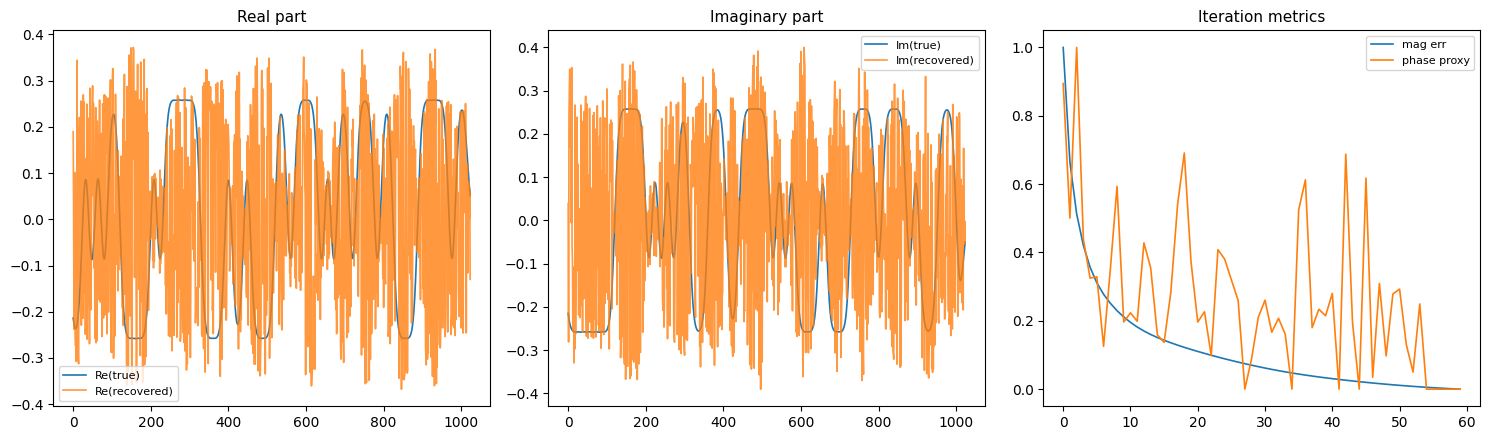

In [21]:
sample = dataset[0]
sig = sample["signal"]
meas1_amp = sample["meas1_amp"]
meas2_amp = sample["meas2_amp"]
dt_local = sample["dt"]
sps_local = sample["sps"]

t_local, f_local, w_local = make_grid(sig.size, dt_local)
D1_local = beta2L_from_ps_per_nm(-353.0)
D2_local = beta2L_from_ps_per_nm(-872.0)

Erec_comm, mag_err_comm, phase_err_comm, hist_comm = tdgsa(
    meas1_amp, meas2_amp, w_local, D1_local, D2_local, n_iter=60
)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax[0].plot(np.real(sig), label="Re(true)")
ax[0].plot(np.real(Erec_comm), label="Re(recovered)", alpha=0.8)
ax[0].set_title("Real part")
ax[0].legend()
ax[1].plot(np.imag(sig), label="Im(true)")
ax[1].plot(np.imag(Erec_comm), label="Im(recovered)", alpha=0.8)
ax[1].set_title("Imaginary part")
ax[1].legend()
ax[2].plot(normalize(mag_err_comm), label="mag err")
ax[2].plot(normalize(phase_err_comm), label="phase proxy")
ax[2].set_title("Iteration metrics")
ax[2].legend()
plt.tight_layout()
plt.show()

## 30. Symbol decisions and EVM

In [22]:
def nearest_qpsk_decisions(x):
    constellation = np.array([1+1j, 1-1j, -1+1j, -1-1j]) / np.sqrt(2)
    d = np.abs(x.reshape(-1, 1) - constellation.reshape(1, -1))
    return np.argmin(d, axis=1), constellation[np.argmin(d, axis=1)]

def sample_symbols(x, sps=16):
    return x[::sps]

true_syms = sample_symbols(sample["true_field"], sps=sps_local)
rec_syms = sample_symbols(Erec_comm, sps=sps_local)

true_idx, _ = nearest_qpsk_decisions(true_syms)
rec_idx, _ = nearest_qpsk_decisions(rec_syms)

symbol_accuracy = np.mean(true_idx == rec_idx)
evm = np.sqrt(np.mean(np.abs(rec_syms - true_syms)**2) / np.mean(np.abs(true_syms)**2))

metrics_df = pd.DataFrame([{
    "symbol_accuracy": symbol_accuracy,
    "evm": evm,
    "n_iter": 60,
    "num_symbols": len(true_syms),
}])
metrics_df

,symbol_accuracy,evm,n_iter,num_symbols
0,0.375,1.372979,60,64


## 31. Dataset-level evaluation

In [23]:
def evaluate_dataset(dataset, n_iter=40):
    rows = []
    for item in dataset:
        sig = item["signal"]
        dt_local = item["dt"]
        sps_local = item["sps"]
        t_local, f_local, w_local = make_grid(sig.size, dt_local)

        D1_local = beta2L_from_ps_per_nm(-353.0)
        D2_local = beta2L_from_ps_per_nm(-872.0)

        Erec, _, _, _ = tdgsa(item["meas1_amp"], item["meas2_amp"], w_local, D1_local, D2_local, n_iter=n_iter)

        true_syms = sample_symbols(sig, sps=sps_local)
        rec_syms = sample_symbols(Erec, sps=sps_local)

        true_idx, _ = nearest_qpsk_decisions(true_syms)
        rec_idx, _ = nearest_qpsk_decisions(rec_syms)

        symbol_accuracy = np.mean(true_idx == rec_idx)
        evm = np.sqrt(np.mean(np.abs(rec_syms - true_syms)**2) / np.mean(np.abs(true_syms)**2))

        rows.append({
            "example_id": item["example_id"],
            "symbol_accuracy": symbol_accuracy,
            "evm": evm,
            "n_iter": n_iter,
        })
    return pd.DataFrame(rows)

eval_df = evaluate_dataset(dataset, n_iter=40)
eval_df.head()

,example_id,symbol_accuracy,evm,n_iter
0,0,0.265625,1.356507,40
1,1,0.250000,1.416995,40
2,2,0.171875,1.411049,40
3,3,0.140625,1.488502,40
4,4,0.312500,1.421773,40


In [24]:
eval_df[["symbol_accuracy", "evm"]].describe()

,symbol_accuracy,evm
count,32.000000,32.000000
mean,0.254395,1.402707
std,0.063031,0.076687
min,0.140625,1.181494
25%,0.203125,1.357162
50%,0.250000,1.416111
75%,0.300781,1.454805
max,0.390625,1.531660


## 32. Communication-facing interpretation

The important shift is:
- from field recovery for its own sake
- to task-level performance

Even if the recovered waveform looks imperfect, the receiver may still be useful if:
- symbol decisions are robust
- EVM is acceptable
- the algorithm converges quickly enough

## 33. Up/down exploration: noise, bandwidth, and aliasing

There are at least four different bottlenecks:

1. optical forward-model mismatch  
2. electronic bandwidth limits  
3. finite sampling rate  
4. algorithmic nonconvergence

## 34. Sweep over noise level

In [25]:
noise_levels = [0.0, 0.005, 0.01, 0.02, 0.05]
rows = []

for noise_std in noise_levels:
    ds = make_comm_dataset(num_examples=8, num_symbols=64, sps=16, noise_std=noise_std)
    df_eval = evaluate_dataset(ds, n_iter=40)
    rows.append({
        "noise_std": noise_std,
        "mean_symbol_accuracy": df_eval["symbol_accuracy"].mean(),
        "mean_evm": df_eval["evm"].mean(),
    })

noise_df = pd.DataFrame(rows)
noise_df

,noise_std,mean_symbol_accuracy,mean_evm
0,0.000,0.267578,1.406082
1,0.005,0.285156,1.357361
2,0.010,0.267578,1.411945
3,0.020,0.212891,1.458382
4,0.050,0.263672,1.418170


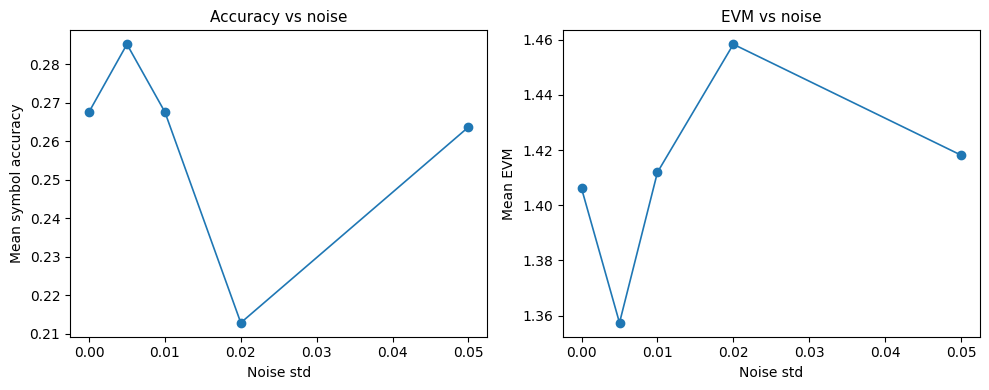

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(noise_df["noise_std"], noise_df["mean_symbol_accuracy"], marker="o")
ax[0].set_title("Accuracy vs noise")
ax[0].set_xlabel("Noise std")
ax[0].set_ylabel("Mean symbol accuracy")

ax[1].plot(noise_df["noise_std"], noise_df["mean_evm"], marker="o")
ax[1].set_title("EVM vs noise")
ax[1].set_xlabel("Noise std")
ax[1].set_ylabel("Mean EVM")
plt.tight_layout()
plt.show()

## 35. Sweep over iteration count

In [27]:
iter_list = [5, 10, 20, 40, 60]
rows = []
for n_iter in iter_list:
    df_eval = evaluate_dataset(dataset[:8], n_iter=n_iter)
    rows.append({
        "n_iter": n_iter,
        "mean_symbol_accuracy": df_eval["symbol_accuracy"].mean(),
        "mean_evm": df_eval["evm"].mean(),
    })

iter_df = pd.DataFrame(rows)
iter_df

,n_iter,mean_symbol_accuracy,mean_evm
0,5,0.263672,1.395303
1,10,0.251953,1.403064
2,20,0.248047,1.458534
3,40,0.281250,1.353441
4,60,0.294922,1.359040


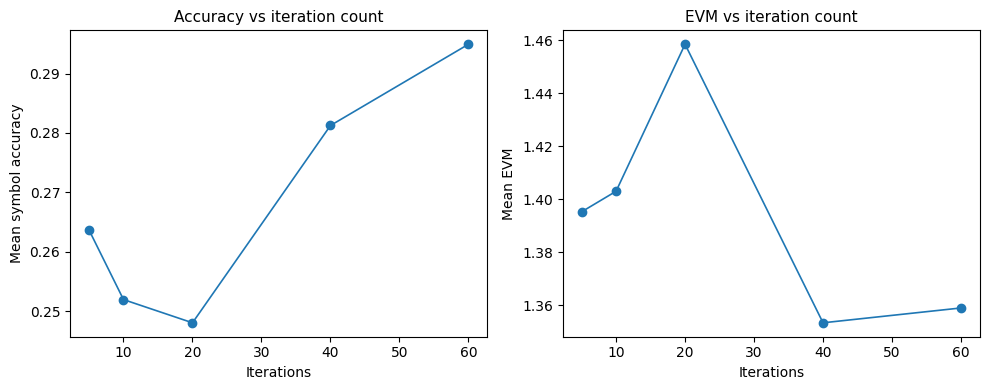

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(iter_df["n_iter"], iter_df["mean_symbol_accuracy"], marker="o")
ax[0].set_title("Accuracy vs iteration count")
ax[0].set_xlabel("Iterations")
ax[0].set_ylabel("Mean symbol accuracy")

ax[1].plot(iter_df["n_iter"], iter_df["mean_evm"], marker="o")
ax[1].set_title("EVM vs iteration count")
ax[1].set_xlabel("Iterations")
ax[1].set_ylabel("Mean EVM")
plt.tight_layout()
plt.show()

## 36. Sweep over dispersion diversity

In [29]:
ratio_list = [1.05, 1.1, 1.33, 2.0, 3.0]
rows = []

sig = dataset[0]["signal"]
dt_local = dataset[0]["dt"]
sps_local = dataset[0]["sps"]
t_local, f_local, w_local = make_grid(sig.size, dt_local)
D1_base = beta2L_from_ps_per_nm(-600.0)
E1_base = apply_dispersion(sig, w_local, D1_base)

for ratio in ratio_list:
    D2_try = ratio * D1_base
    E2_try = apply_dispersion(sig, w_local, D2_try)
    Erec_try, _, _, _ = tdgsa(np.abs(E1_base), np.abs(E2_try), w_local, D1_base, D2_try, n_iter=30)

    true_syms = sample_symbols(sig, sps=sps_local)
    rec_syms = sample_symbols(Erec_try, sps=sps_local)

    true_idx, _ = nearest_qpsk_decisions(true_syms)
    rec_idx, _ = nearest_qpsk_decisions(rec_syms)

    acc = np.mean(true_idx == rec_idx)
    evm = np.sqrt(np.mean(np.abs(rec_syms - true_syms)**2) / np.mean(np.abs(true_syms)**2))

    rows.append({"ratio": ratio, "symbol_accuracy": acc, "evm": evm})

ratio_df = pd.DataFrame(rows)
ratio_df

,ratio,symbol_accuracy,evm
0,1.05,0.296875,1.416076
1,1.10,0.250000,1.427823
2,1.33,0.296875,1.399317
3,2.00,0.140625,1.492372
4,3.00,0.203125,1.444667


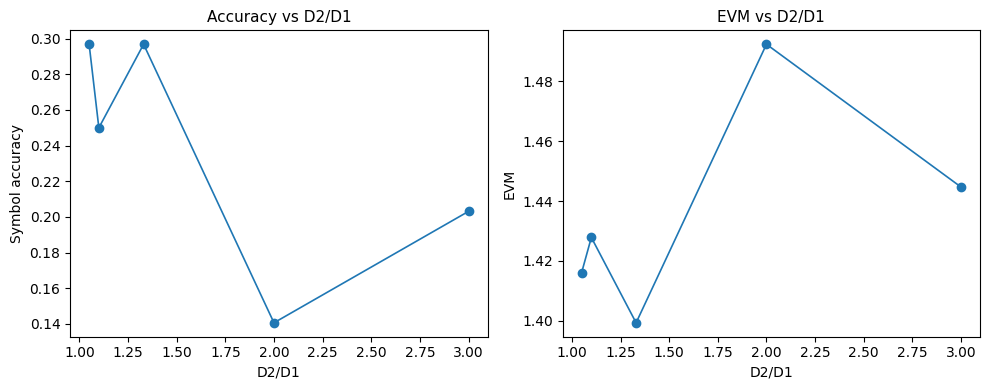

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(ratio_df["ratio"], ratio_df["symbol_accuracy"], marker="o")
ax[0].set_title("Accuracy vs D2/D1")
ax[0].set_xlabel("D2/D1")
ax[0].set_ylabel("Symbol accuracy")

ax[1].plot(ratio_df["ratio"], ratio_df["evm"], marker="o")
ax[1].set_title("EVM vs D2/D1")
ax[1].set_xlabel("D2/D1")
ax[1].set_ylabel("EVM")
plt.tight_layout()
plt.show()

## 37. Into/out of the receiver boundary

### Outside
- the transmitter waveform
- the optical channel
- the dispersive hardware
- photodetection and ADC physics

### Inside
- discrete preprocessing
- unit normalization
- TDGSA loop
- optional ML or gradient-based alternatives
- symbol decision and performance metrics

## 38. Engineering flow control

A practical implementation should be staged.

### Stage A
Single Gaussian / chirped Gaussian

### Stage B
Gas-cell-like absorption features

### Stage C
Communication-like modulated signals

### Stage D
Real provided optical communication dataset

### Stage E
Comparison against MATLAB and Torch baselines

## 39. Economic model framing

In [31]:
economic_df = pd.DataFrame([
    {
        "receiver_type": "TDGSA carrier-less",
        "optics_hardware": "2 dispersive paths + 2 photodiodes + ADC",
        "compute_path": "iterative reconstruction",
        "latency_risk": "high",
        "calibration_burden": "moderate-high",
        "main_advantage": "no local oscillator"
    },
    {
        "receiver_type": "Conventional coherent",
        "optics_hardware": "local oscillator + coherent front-end",
        "compute_path": "standard DSP chain",
        "latency_risk": "medium",
        "calibration_burden": "high",
        "main_advantage": "mature and validated"
    },
    {
        "receiver_type": "AI-assisted retrieval",
        "optics_hardware": "same front-end as intensity-based scheme",
        "compute_path": "training + inference",
        "latency_risk": "deployment dependent",
        "calibration_burden": "retraining-sensitive",
        "main_advantage": "can learn nonideal distortions"
    }
])
economic_df

,receiver_type,optics_hardware,compute_path,latency_risk,calibration_burden,main_advantage
0,TDGSA carrier-less,2 dispersive paths + 2 photodiodes + ADC,iterative reconstruction,high,moderate-high,no local oscillator
1,Conventional coherent,local oscillator + coherent front-end,standard DSP chain,medium,high,mature and validated
2,AI-assisted retrieval,same front-end as intensity-based scheme,training + inference,deployment dependent,retraining-sensitive,can learn nonideal distortions


## 40. Economic interpretation

A cheap optical front-end can become expensive once:
- two lines are required
- calibration is frequent
- iteration counts are high
- compute latency becomes a bottleneck

So the right comparison is not simply:
“TDGSA avoids a local oscillator”

The right comparison is:
“TDGSA trades optical complexity for measurement redundancy and computation.”

## 41. Torch baseline scaffold

In [32]:
if TORCH_AVAILABLE:
    class TinyRegressor(torch.nn.Module):
        def __init__(self, n):
            super().__init__()
            self.net = torch.nn.Sequential(
                torch.nn.Linear(2 * n, 512),
                torch.nn.ReLU(),
                torch.nn.Linear(512, 512),
                torch.nn.ReLU(),
                torch.nn.Linear(512, 2 * n),
            )

        def forward(self, x):
            return self.net(x)

    print("Torch baseline scaffold is ready.")
else:
    print("Torch is not available in this environment.")

Torch baseline scaffold is ready.


## 42. Gradient-descent baseline idea

A useful comparison is:
- TDGSA amplitude replacement
versus
- direct gradient descent on a loss function

Example loss:
- mismatch with measurement 1 amplitude
- mismatch with measurement 2 amplitude
- optional regularization on phase smoothness

## 43. Gradient-descent pseudo-objective

In [33]:
amp1_sym, amp2_sym = sp.symbols("amp1 amp2", positive=True, real=True)
loss_form = (amp1_sym - amp2_sym)**2
loss_form

(amp1 - amp2)**2

A realistic optimization objective would be:

$
\mathcal{{L}}(E) =
\| |P_{{D1}}(E)| - m_1 \|^2 +
\| |P_{{D2}}(E)| - m_2 \|^2 +
\lambda R(E)
$

## 44. File discovery hooks

In [34]:
def discover_files(root="."):
    root = Path(root)
    patterns = ["*.csv", "*.txt", "*.dat", "*.mat", "*.npy", "*.npz", "*.png", "*.jpg", "*.ipynb"]
    found = {}
    for pat in patterns:
        found[pat] = sorted(str(p) for p in root.rglob(pat))
    return found

def parse_numeric_from_name(name):
    nums = re.findall(r"[-+]?[0-9]*\.?[0-9]+", Path(name).name)
    return [float(n) for n in nums]

files_found = discover_files(".")
{k: len(v) for k, v in files_found.items()}

{'*.csv': 0,
 '*.txt': 0,
 '*.dat': 0,
 '*.mat': 0,
 '*.npy': 0,
 '*.npz': 0,
 '*.png': 110,
 '*.jpg': 0,
 '*.ipynb': 100}

## 45. Suggested schema for provided optical communication data

Suggested fields:
- `example_id`
- `time`
- `measurement_line_1`
- `measurement_line_2`
- `sampling_rate`
- `D1`
- `D2`
- `symbol_rate`
- `carrier_info` if any
- `ground_truth_symbols` if available
- `ground_truth_phase` if available

## 46. Create a template dataset table

In [35]:
schema_df = pd.DataFrame([
    {"field": "example_id", "meaning": "record identifier"},
    {"field": "time", "meaning": "time axis in seconds"},
    {"field": "measurement_line_1", "meaning": "intensity or amplitude after D1"},
    {"field": "measurement_line_2", "meaning": "intensity or amplitude after D2"},
    {"field": "sampling_rate", "meaning": "ADC rate in samples per second"},
    {"field": "D1", "meaning": "first dispersion setting"},
    {"field": "D2", "meaning": "second dispersion setting"},
    {"field": "symbol_rate", "meaning": "communication symbol rate"},
    {"field": "ground_truth_symbols", "meaning": "reference decisions if known"},
    {"field": "ground_truth_phase", "meaning": "reference phase if known"},
])
schema_df

,field,meaning
0,example_id,record identifier
1,time,time axis in seconds
2,measurement_line_1,intensity or amplitude after D1
3,measurement_line_2,intensity or amplitude after D2
4,sampling_rate,ADC rate in samples per second
5,D1,first dispersion setting
6,D2,second dispersion setting
7,symbol_rate,communication symbol rate
8,ground_truth_symbols,reference decisions if known
9,ground_truth_phase,reference phase if known


## 47. Frame export scaffold for TDGSA

In [37]:
def save_tdgsa_frames(history, t, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for item in history:
        k = item["iter"]
        E1k = item["E1"]
        E2k = item["E2"]
        me = item["mag_err"]
        pe = item["phase_err"]

        fig, ax = plt.subplots(1, 3, figsize=(14, 4))
        ax[0].plot(t * 1e9, normalize(np.abs(E1k)))
        ax[0].set_title(f"Plane 1 amplitude, iter {k}")
        ax[0].set_xlabel("Time (ns)")

        ax[1].plot(t * 1e9, normalize(np.abs(E2k)))
        ax[1].set_title(f"Plane 2 amplitude, iter {k}")
        ax[1].set_xlabel("Time (ns)")

        ax[2].plot(np.unwrap(np.angle(E1k)))
        ax[2].set_title(f"mag={me:.3e}, phase={pe:.3e}")
        ax[2].set_xlabel("Sample index")

        plt.tight_layout()
        fig.savefig(out_dir / f"frame_{k:04d}.png", dpi=140)
        plt.close(fig)

# Uncomment when ready:
save_tdgsa_frames(hist_g, t, "tdgsa_frames")

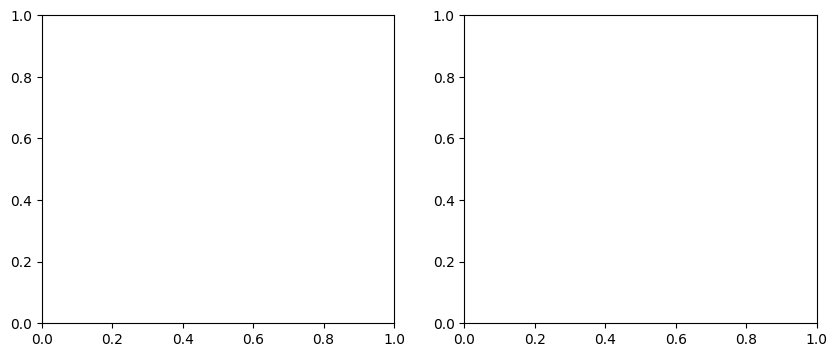

In [139]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def animate_tdgsa(history, t, interval=50):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    def update(frame):
        ax[0].cla()
        ax[1].cla()

        item = history[frame]
        E1 = item["E1"]
        err = item["mag_err"]

        ax[0].plot(t * 1e9, np.abs(E1))
        ax[0].set_title(f"Amplitude (iter {frame+1})")
        ax[0].set_xlabel("Time (ns)")

        ax[1].plot(np.unwrap(np.angle(E1)))
        ax[1].set_title(f"Phase (err={err:.3e})")

    anim = FuncAnimation(fig, update, frames=len(history), interval=interval)
    return anim

# usage
anim = animate_tdgsa(hist_g, t)
plt.show()

In [140]:
import imageio
from pathlib import Path

def frames_to_gif(frame_dir, output="tdgsa.gif", fps=20):
    frame_dir = Path(frame_dir)
    files = sorted(frame_dir.glob("frame_*.png"))

    images = [imageio.imread(f) for f in files]
    imageio.mimsave(output, images, fps=fps)

# usage
frames_to_gif("tdgsa_frames", "tdgsa.gif", fps=20)

C:\Users\mrjel\AppData\Local\Temp\ipykernel_41004\1541902749.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images = [imageio.imread(f) for f in files]


## 48. Notebook-wide conclusions

### What is corrected here
- TDGSA is framed as a two-measurement iterative algorithm
- unit and dimension issues are surfaced instead of ignored
- communication metrics are included
- algorithm diversity and initialization are treated as first-class topics
- economics and deployment risks are explicitly part of the engineering story

### What still needs lab or source-code confirmation
- exact MATLAB conventions
- exact dispersion conversion
- exact absorption and causal phase model
- real communication dataset for Task 5
- exact forward-model assumptions used in the original project

## 49. Public-facing caution

If this notebook is used on GitHub or LinkedIn, describe it honestly as:
- an exploratory reconstruction notebook
- based on the project brief and cited papers
- with some forward-model placeholders still under validation

## 50. Technical note 1

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [38]:
# Technical note 1: placeholder probe cell
note_index = 1
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 1,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 51. Technical note 2

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [39]:
# Technical note 2: placeholder probe cell
note_index = 2
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 2,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 52. Technical note 3

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [40]:
# Technical note 3: placeholder probe cell
note_index = 3
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 3,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 53. Technical note 4

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [41]:
# Technical note 4: placeholder probe cell
note_index = 4
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 4,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 54. Technical note 5

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [42]:
# Technical note 5: placeholder probe cell
note_index = 5
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 5,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 55. Technical note 6

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [43]:
# Technical note 6: placeholder probe cell
note_index = 6
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 6,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 56. Technical note 7

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [44]:
# Technical note 7: placeholder probe cell
note_index = 7
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 7,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 57. Technical note 8

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [45]:
# Technical note 8: placeholder probe cell
note_index = 8
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 8,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 58. Technical note 9

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [46]:
# Technical note 9: placeholder probe cell
note_index = 9
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 9,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 59. Technical note 10

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [47]:
# Technical note 10: placeholder probe cell
note_index = 10
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 10,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 60. Technical note 11

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [48]:
# Technical note 11: placeholder probe cell
note_index = 11
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 11,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 61. Technical note 12

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [49]:
# Technical note 12: placeholder probe cell
note_index = 12
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 12,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 62. Technical note 13

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [50]:
# Technical note 13: placeholder probe cell
note_index = 13
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 13,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 63. Technical note 14

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [51]:
# Technical note 14: placeholder probe cell
note_index = 14
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 14,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 64. Technical note 15

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [52]:
# Technical note 15: placeholder probe cell
note_index = 15
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 15,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 65. Technical note 16

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [53]:
# Technical note 16: placeholder probe cell
note_index = 16
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 16,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 66. Technical note 17

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [54]:
# Technical note 17: placeholder probe cell
note_index = 17
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 17,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 67. Technical note 18

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [55]:
# Technical note 18: placeholder probe cell
note_index = 18
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 18,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 68. Technical note 19

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [56]:
# Technical note 19: placeholder probe cell
note_index = 19
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 19,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 69. Technical note 20

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [57]:
# Technical note 20: placeholder probe cell
note_index = 20
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 20,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 70. Technical note 21

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [58]:
# Technical note 21: placeholder probe cell
note_index = 21
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 21,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 71. Technical note 22

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [59]:
# Technical note 22: placeholder probe cell
note_index = 22
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 22,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 72. Technical note 23

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [60]:
# Technical note 23: placeholder probe cell
note_index = 23
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 23,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 73. Technical note 24

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [61]:
# Technical note 24: placeholder probe cell
note_index = 24
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 24,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 74. Technical note 25

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [62]:
# Technical note 25: placeholder probe cell
note_index = 25
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 25,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 75. Technical note 26

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [63]:
# Technical note 26: placeholder probe cell
note_index = 26
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 26,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 76. Technical note 27

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [64]:
# Technical note 27: placeholder probe cell
note_index = 27
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 27,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 77. Technical note 28

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [65]:
# Technical note 28: placeholder probe cell
note_index = 28
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 28,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 78. Technical note 29

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [66]:
# Technical note 29: placeholder probe cell
note_index = 29
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 29,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 79. Technical note 30

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [67]:
# Technical note 30: placeholder probe cell
note_index = 30
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 30,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 80. Technical note 31

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [68]:
# Technical note 31: placeholder probe cell
note_index = 31
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 31,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 81. Technical note 32

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [69]:
# Technical note 32: placeholder probe cell
note_index = 32
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 32,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 82. Technical note 33

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [70]:
# Technical note 33: placeholder probe cell
note_index = 33
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 33,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 83. Technical note 34

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [71]:
# Technical note 34: placeholder probe cell
note_index = 34
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 34,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 84. Technical note 35

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [72]:
# Technical note 35: placeholder probe cell
note_index = 35
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 35,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 85. Technical note 36

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [73]:
# Technical note 36: placeholder probe cell
note_index = 36
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 36,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 86. Technical note 37

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [74]:
# Technical note 37: placeholder probe cell
note_index = 37
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 37,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 87. Technical note 38

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [75]:
# Technical note 38: placeholder probe cell
note_index = 38
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 38,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 88. Technical note 39

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [76]:
# Technical note 39: placeholder probe cell
note_index = 39
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 39,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 89. Technical note 40

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [77]:
# Technical note 40: placeholder probe cell
note_index = 40
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 40,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 90. Technical note 41

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [78]:
# Technical note 41: placeholder probe cell
note_index = 41
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 41,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 91. Technical note 42

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [79]:
# Technical note 42: placeholder probe cell
note_index = 42
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 42,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 92. Technical note 43

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [80]:
# Technical note 43: placeholder probe cell
note_index = 43
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 43,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 93. Technical note 44

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [81]:
# Technical note 44: placeholder probe cell
note_index = 44
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 44,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 94. Technical note 45

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [82]:
# Technical note 45: placeholder probe cell
note_index = 45
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 45,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 95. Technical note 46

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [83]:
# Technical note 46: placeholder probe cell
note_index = 46
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 46,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 96. Technical note 47

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [84]:
# Technical note 47: placeholder probe cell
note_index = 47
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 47,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 97. Technical note 48

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [85]:
# Technical note 48: placeholder probe cell
note_index = 48
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 48,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 98. Technical note 49

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [86]:
# Technical note 49: placeholder probe cell
note_index = 49
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 49,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 99. Technical note 50

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [87]:
# Technical note 50: placeholder probe cell
note_index = 50
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 50,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 100. Technical note 51

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [88]:
# Technical note 51: placeholder probe cell
note_index = 51
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 51,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 101. Technical note 52

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [89]:
# Technical note 52: placeholder probe cell
note_index = 52
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 52,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 102. Technical note 53

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [90]:
# Technical note 53: placeholder probe cell
note_index = 53
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 53,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 103. Technical note 54

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [91]:
# Technical note 54: placeholder probe cell
note_index = 54
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 54,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 104. Technical note 55

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [92]:
# Technical note 55: placeholder probe cell
note_index = 55
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 55,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 105. Technical note 56

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [93]:
# Technical note 56: placeholder probe cell
note_index = 56
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 56,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 106. Technical note 57

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [94]:
# Technical note 57: placeholder probe cell
note_index = 57
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 57,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 107. Technical note 58

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [95]:
# Technical note 58: placeholder probe cell
note_index = 58
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 58,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 108. Technical note 59

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [96]:
# Technical note 59: placeholder probe cell
note_index = 59
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 59,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 109. Technical note 60

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [97]:
# Technical note 60: placeholder probe cell
note_index = 60
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 60,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 110. Technical note 61

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [98]:
# Technical note 61: placeholder probe cell
note_index = 61
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 61,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 111. Technical note 62

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [99]:
# Technical note 62: placeholder probe cell
note_index = 62
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 62,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 112. Technical note 63

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [100]:
# Technical note 63: placeholder probe cell
note_index = 63
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 63,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 113. Technical note 64

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [101]:
# Technical note 64: placeholder probe cell
note_index = 64
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 64,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 114. Technical note 65

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [102]:
# Technical note 65: placeholder probe cell
note_index = 65
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 65,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 115. Technical note 66

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [103]:
# Technical note 66: placeholder probe cell
note_index = 66
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 66,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 116. Technical note 67

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [104]:
# Technical note 67: placeholder probe cell
note_index = 67
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 67,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 117. Technical note 68

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [105]:
# Technical note 68: placeholder probe cell
note_index = 68
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 68,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 118. Technical note 69

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [106]:
# Technical note 69: placeholder probe cell
note_index = 69
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 69,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 119. Technical note 70

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [107]:
# Technical note 70: placeholder probe cell
note_index = 70
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 70,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 120. Technical note 71

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [108]:
# Technical note 71: placeholder probe cell
note_index = 71
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 71,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 121. Technical note 72

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [109]:
# Technical note 72: placeholder probe cell
note_index = 72
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 72,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 122. Technical note 73

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [110]:
# Technical note 73: placeholder probe cell
note_index = 73
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 73,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 123. Technical note 74

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [111]:
# Technical note 74: placeholder probe cell
note_index = 74
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 74,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 124. Technical note 75

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [112]:
# Technical note 75: placeholder probe cell
note_index = 75
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 75,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 125. Technical note 76

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [113]:
# Technical note 76: placeholder probe cell
note_index = 76
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 76,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 126. Technical note 77

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [114]:
# Technical note 77: placeholder probe cell
note_index = 77
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 77,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 127. Technical note 78

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [115]:
# Technical note 78: placeholder probe cell
note_index = 78
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 78,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 128. Technical note 79

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [116]:
# Technical note 79: placeholder probe cell
note_index = 79
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 79,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 129. Technical note 80

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [117]:
# Technical note 80: placeholder probe cell
note_index = 80
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 80,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 130. Technical note 81

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [118]:
# Technical note 81: placeholder probe cell
note_index = 81
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 81,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 131. Technical note 82

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [119]:
# Technical note 82: placeholder probe cell
note_index = 82
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 82,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 132. Technical note 83

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [120]:
# Technical note 83: placeholder probe cell
note_index = 83
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 83,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 133. Technical note 84

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [121]:
# Technical note 84: placeholder probe cell
note_index = 84
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 84,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 134. Technical note 85

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [122]:
# Technical note 85: placeholder probe cell
note_index = 85
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 85,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 135. Technical note 86

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [123]:
# Technical note 86: placeholder probe cell
note_index = 86
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 86,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 136. Technical note 87

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [124]:
# Technical note 87: placeholder probe cell
note_index = 87
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 87,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 137. Technical note 88

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [125]:
# Technical note 88: placeholder probe cell
note_index = 88
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 88,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 138. Technical note 89

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [126]:
# Technical note 89: placeholder probe cell
note_index = 89
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 89,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 139. Technical note 90

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [127]:
# Technical note 90: placeholder probe cell
note_index = 90
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 90,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 140. Technical note 91

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [128]:
# Technical note 91: placeholder probe cell
note_index = 91
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 91,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 141. Technical note 92

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [129]:
# Technical note 92: placeholder probe cell
note_index = 92
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 92,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 142. Technical note 93

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [130]:
# Technical note 93: placeholder probe cell
note_index = 93
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 93,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 143. Technical note 94

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [131]:
# Technical note 94: placeholder probe cell
note_index = 94
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 94,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 144. Technical note 95

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [132]:
# Technical note 95: placeholder probe cell
note_index = 95
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 95,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 145. Technical note 96

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [133]:
# Technical note 96: placeholder probe cell
note_index = 96
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 96,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 146. Technical note 97

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [134]:
# Technical note 97: placeholder probe cell
note_index = 97
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 97,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 147. Technical note 98

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [135]:
# Technical note 98: placeholder probe cell
note_index = 98
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 98,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 148. Technical note 99

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [136]:
# Technical note 99: placeholder probe cell
note_index = 99
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 99,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 149. Technical note 100

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [137]:
# Technical note 100: placeholder probe cell
note_index = 100
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 100,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}

## 150. Technical note 101

This section is intentionally short and focused.

### Checklist item
- inspect assumptions
- inspect units
- inspect convergence behavior
- inspect receiver-facing metrics

### Practical question
What enters the block, what leaves the block, and what hidden normalization or unit conversion is being assumed?

### Suggested next action
Write a small test before expanding the model.

In [138]:
# Technical note 101: placeholder probe cell
note_index = 101
probe = {
    "note_index": note_index,
    "N1D": PARAMS["N1D"],
    "dt": PARAMS["dt"],
    "T0_ns": PARAMS["T0_ns"],
    "tau_ns": PARAMS["tau_ns"],
    "iterations": PARAMS["n_iter"],
}
probe

{'note_index': 101,
 'N1D': 4096,
 'dt': 5e-12,
 'T0_ns': 2.0,
 'tau_ns': 20.0,
 'iterations': 100}